# 3. Classification

**Purpose:** compare all classification feature sets on valid binary cohorts only.

**Rule:** no classification is performed on `full`, because some patients have unknown 7-year status.

In [1]:
from pathlib import Path
import sys
import subprocess
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA = ROOT / 'data' / 'processed'
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
VENV_PY = ROOT / '.venv' / 'Scripts' / 'python.exe'
PIPELINE_PY = VENV_PY if VENV_PY.exists() else Path(sys.executable)
FEATURE_SETS = [
    'CV17', 'CV17_THY26', 'CV17_BIN', 'CV17_ORD',
    'CV17_CONT', 'CV17_CAT', 'CV17_RATIO', 'CV17_RATIO_ONLY'
]

def read_csv(name, folder=DATA, **kwargs):
    path = folder / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)

def show_image(path, width=850):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f'Missing figure: {path}')

def run_step(step, force=False):
    cmd = [str(PIPELINE_PY), str(ROOT / 'run_pipeline.py'), '--step', step]
    if force:
        cmd.append('--force')
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)

def pct(x):
    return f'{100*x:.1f}%'

## How to use this notebook

- Screening: broad model/sampler exploration.
- Robust CV: primary comparison for feature sets.
- Tuning: leader-model refinement across all feature sets after the latest code updates.

In [2]:
RUN_PIPELINE_STEPS = False
if RUN_PIPELINE_STEPS:
    run_step('screening', force=False)
    run_step('robust_cv', force=False)
    run_step('tuning', force=False)
else:
    print('Using existing classification artefacts. Set RUN_PIPELINE_STEPS=True to regenerate with .venv.')

Using existing classification artefacts. Set RUN_PIPELINE_STEPS=True to regenerate with .venv.


## 3.1 Experiment completeness

This table is deliberately upfront: it tells the team whether the artefacts reflect the intended full matrix.

In [3]:
expected = {'screening': 2 * 8 * 8 * 5, 'robust_cv': 2 * 8 * 4, 'tuning': 2 * 8 * 4}
clf = read_csv('results_clf.csv') if (DATA / 'results_clf.csv').exists() else pd.DataFrame()
cv = read_csv('results_cv.csv') if (DATA / 'results_cv.csv').exists() else pd.DataFrame()
tune = read_csv('results_tune.csv') if (DATA / 'results_tune.csv').exists() else pd.DataFrame()
complete = pd.DataFrame([
    {'block': 'screening', 'rows': len(clf), 'expected': expected['screening'], 'complete': len(clf) == expected['screening']},
    {'block': 'robust_cv', 'rows': len(cv), 'expected': expected['robust_cv'], 'complete': len(cv) == expected['robust_cv']},
    {'block': 'tuning', 'rows': len(tune), 'expected': expected['tuning'], 'complete': len(tune) == expected['tuning']},
])
display(complete)

,block,rows,expected,complete
0,screening,640,640,True
1,robust_cv,64,64,True
2,tuning,58,64,False


## 3.2 Screening overview

Single split screening is exploratory. Use it to see model/sampler behaviour, not as final evidence.

In [4]:
if not clf.empty:
    best = (clf.sort_values('f1_macro', ascending=False)
              .groupby(['cohort', 'feature_set']).head(1)
              [['cohort','feature_set','model','sampler','f1_macro','roc_auc','pr_auc']])
    display(best.sort_values(['cohort', 'f1_macro'], ascending=[True, False]))
else:
    print('No screening results.')

,cohort,feature_set,model,sampler,f1_macro,roc_auc,pr_auc
424,competing,CV17_BIN,AdaBoost,SVMSMOTE,0.668655,0.791762,0.431925
324,competing,CV17,LogisticRegression,SVMSMOTE,0.660074,0.798390,0.420508
624,competing,CV17_RATIO_ONLY,AdaBoost,SVMSMOTE,0.659191,0.788139,0.406412
464,competing,CV17_ORD,AdaBoost,SVMSMOTE,0.657233,0.782445,0.389143
484,competing,CV17_CONT,LogisticRegression,SVMSMOTE,0.656713,0.789287,0.415692
582,competing,CV17_RATIO,AdaBoost,SMOTE,0.656044,0.772941,0.419622
384,competing,CV17_THY26,AdaBoost,SVMSMOTE,0.655814,0.790342,0.409346
544,competing,CV17_CAT,AdaBoost,SVMSMOTE,0.651287,0.781713,0.384850
179,strict,CV17_CONT,RandomForest,SVMSMOTE,0.750451,0.834863,0.639592
268,strict,CV17_RATIO,HistGradientBoosting,BorderlineSMOTE,0.746825,0.822602,0.615702


## 3.3 Robust CV: primary classification evidence

The key question: does any thyroid feature set improve over `CV17` beyond fold variability?

In [5]:
if not cv.empty:
    best_cv = (cv.sort_values('f1_macro_opt_mean', ascending=False)
                 .groupby(['cohort', 'feature_set']).head(1))
    display(best_cv[['cohort','feature_set','model','sampler','f1_macro_opt_mean','f1_macro_opt_std','roc_auc_mean','roc_auc_std','threshold_mean']]
            .sort_values(['cohort','f1_macro_opt_mean'], ascending=[True, False]))
    rows = []
    for cohort in ['strict','competing']:
        sub = cv[cv['cohort'].eq(cohort)]
        base = sub[sub['feature_set'].eq('CV17')][['model','f1_macro_opt_mean','roc_auc_mean']].rename(columns={'f1_macro_opt_mean':'base_f1','roc_auc_mean':'base_auc'})
        merged = sub.merge(base, on='model')
        merged['delta_f1_vs_cv17'] = merged['f1_macro_opt_mean'] - merged['base_f1']
        merged['delta_auc_vs_cv17'] = merged['roc_auc_mean'] - merged['base_auc']
        rows.append(merged)
    deltas = pd.concat(rows)
    display(deltas[['cohort','feature_set','model','delta_f1_vs_cv17','delta_auc_vs_cv17']]
            .sort_values(['cohort','delta_f1_vs_cv17'], ascending=[True, False]))
else:
    print('No robust CV results.')

,cohort,feature_set,model,sampler,f1_macro_opt_mean,f1_macro_opt_std,roc_auc_mean,roc_auc_std,threshold_mean
48,competing,CV17_CONT,LogisticRegression,SMOTE,0.649026,0.010780,0.777043,0.015516,0.692
32,competing,CV17,LogisticRegression,SMOTE,0.646926,0.013107,0.777712,0.016391,0.676
60,competing,CV17_RATIO_ONLY,LogisticRegression,SMOTE,0.646831,0.010374,0.776995,0.015413,0.696
44,competing,CV17_ORD,LogisticRegression,SMOTE,0.646747,0.009095,0.777669,0.016049,0.696
56,competing,CV17_RATIO,LogisticRegression,SMOTE,0.643716,0.010514,0.777180,0.016752,0.700
52,competing,CV17_CAT,LogisticRegression,SMOTE,0.643304,0.014484,0.777387,0.016631,0.700
36,competing,CV17_THY26,LogisticRegression,SMOTE,0.640689,0.010307,0.776791,0.016408,0.700
40,competing,CV17_BIN,LogisticRegression,SMOTE,0.638700,0.011052,0.777598,0.016757,0.684
28,strict,CV17_RATIO_ONLY,LogisticRegression,SMOTE,0.733550,0.016542,0.839650,0.016185,0.656
16,strict,CV17_CONT,LogisticRegression,SMOTE,0.733106,0.034637,0.839614,0.015687,0.684


,cohort,feature_set,model,delta_f1_vs_cv17,delta_auc_vs_cv17
17,competing,CV17_CONT,RandomForest,0.023170,0.014171
5,competing,CV17_THY26,RandomForest,0.016706,0.013362
25,competing,CV17_RATIO,RandomForest,0.016502,0.009107
6,competing,CV17_THY26,HistGradientBoosting,0.012081,0.002412
22,competing,CV17_CAT,HistGradientBoosting,0.011153,0.000983
...,...,...,...,...,...
20,strict,CV17_CAT,LogisticRegression,-0.004715,-0.000941
30,strict,CV17_RATIO_ONLY,HistGradientBoosting,-0.006382,-0.005515
24,strict,CV17_RATIO,LogisticRegression,-0.006769,-0.001947
4,strict,CV17_THY26,LogisticRegression,-0.007939,-0.001981


## 3.4 Tuning across feature sets

After the code update, intended tuning coverage is `strict/competing ? 8 feature sets ? 4 leader models`. If the completeness table shows 24 rows, these are legacy artefacts and should be regenerated.

In [6]:
if not tune.empty:
    cols = ['cohort','feature_set','model','sampler','cv_f1_macro','best_params']
    for c in ['cv_f1_macro_threshold','cv_auc','cv_threshold_mean','optimal_threshold','train_auc']:
        if c in tune.columns and c not in cols:
            cols.insert(-1, c)
    sort_cols = [c for c in ['cohort','cv_f1_macro_threshold','cv_f1_macro'] if c in tune.columns]
    display(tune[cols].sort_values(sort_cols, ascending=[True] + [False]*(len(sort_cols)-1)))
else:
    print('No tuning results.')

,cohort,feature_set,model,sampler,cv_f1_macro,cv_f1_macro_threshold,cv_auc,cv_threshold_mean,optimal_threshold,train_auc,best_params
32,competing,CV17,LogisticRegression,SVMSMOTE,0.644197,0.654559,0.776286,0.645,0.64,0.783741,"{'clf__penalty': 'l2', 'clf__C': 1}"
40,competing,CV17_BIN,LogisticRegression,SVMSMOTE,0.643068,0.653718,0.775511,0.600,0.64,0.784013,"{'clf__penalty': 'l2', 'clf__C': 0.01}"
56,competing,CV17_RATIO,LogisticRegression,SVMSMOTE,0.642444,0.653610,0.773889,0.645,0.68,0.784240,"{'clf__penalty': 'l2', 'clf__C': 1}"
44,competing,CV17_ORD,LogisticRegression,SVMSMOTE,0.643731,0.653608,0.775619,0.635,0.60,0.782506,"{'clf__penalty': 'l2', 'clf__C': 5}"
52,competing,CV17_CAT,LogisticRegression,SVMSMOTE,0.639825,0.653508,0.774468,0.640,0.68,0.784658,"{'clf__penalty': 'l2', 'clf__C': 0.01}"
48,competing,CV17_CONT,LogisticRegression,SVMSMOTE,0.643637,0.651521,0.773982,0.615,0.60,0.782771,"{'clf__penalty': 'l2', 'clf__C': 0.01}"
39,competing,CV17_THY26,XGBoost,SVMSMOTE,0.649917,0.649923,0.774089,0.520,0.58,0.797232,"{'clf__subsample': 0.9, 'clf__n_estimators': 1..."
36,competing,CV17_THY26,LogisticRegression,SVMSMOTE,0.642371,0.649841,0.773814,0.635,0.64,0.784265,"{'clf__penalty': 'l2', 'clf__C': 5}"
51,competing,CV17_CONT,XGBoost,SVMSMOTE,0.649920,0.648253,0.763971,0.475,0.46,0.896069,"{'clf__subsample': 0.8, 'clf__n_estimators': 1..."
35,competing,CV17,XGBoost,SVMSMOTE,0.645471,0.647959,0.769385,0.480,0.48,0.802295,"{'clf__subsample': 0.7, 'clf__n_estimators': 3..."


## 3.5 Communication plots

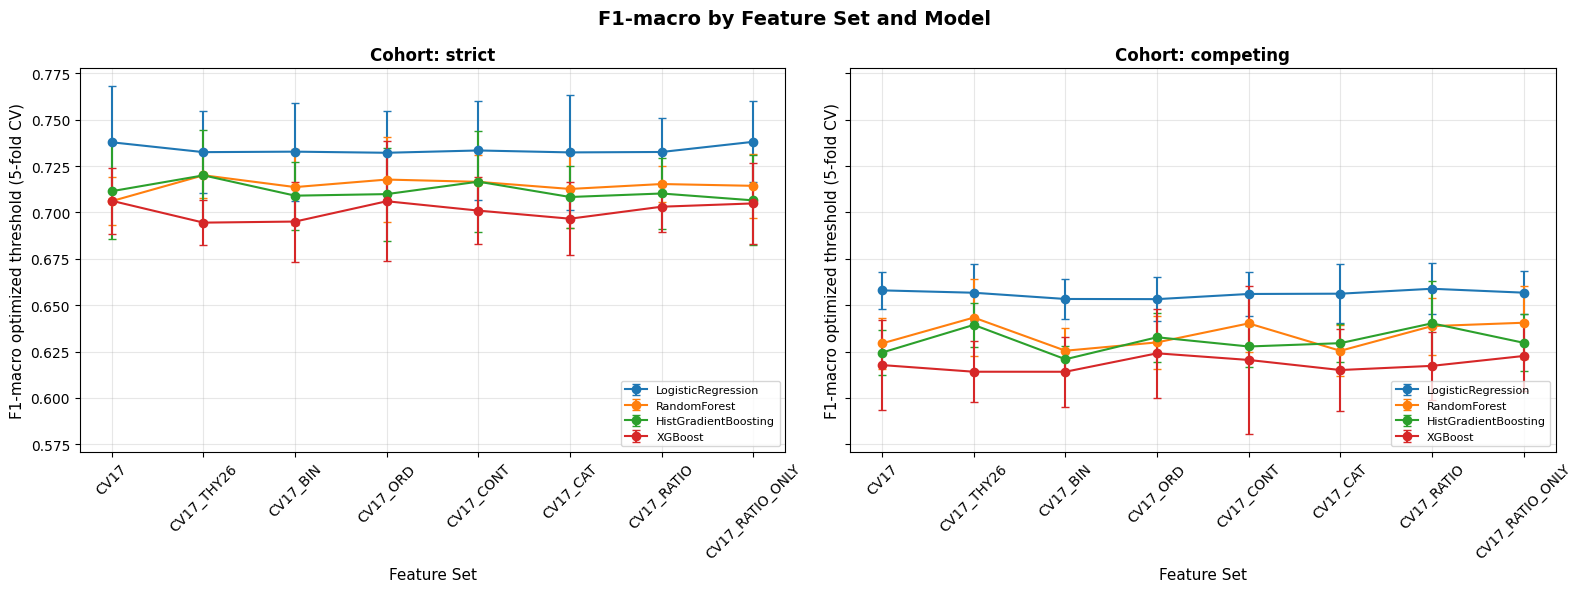

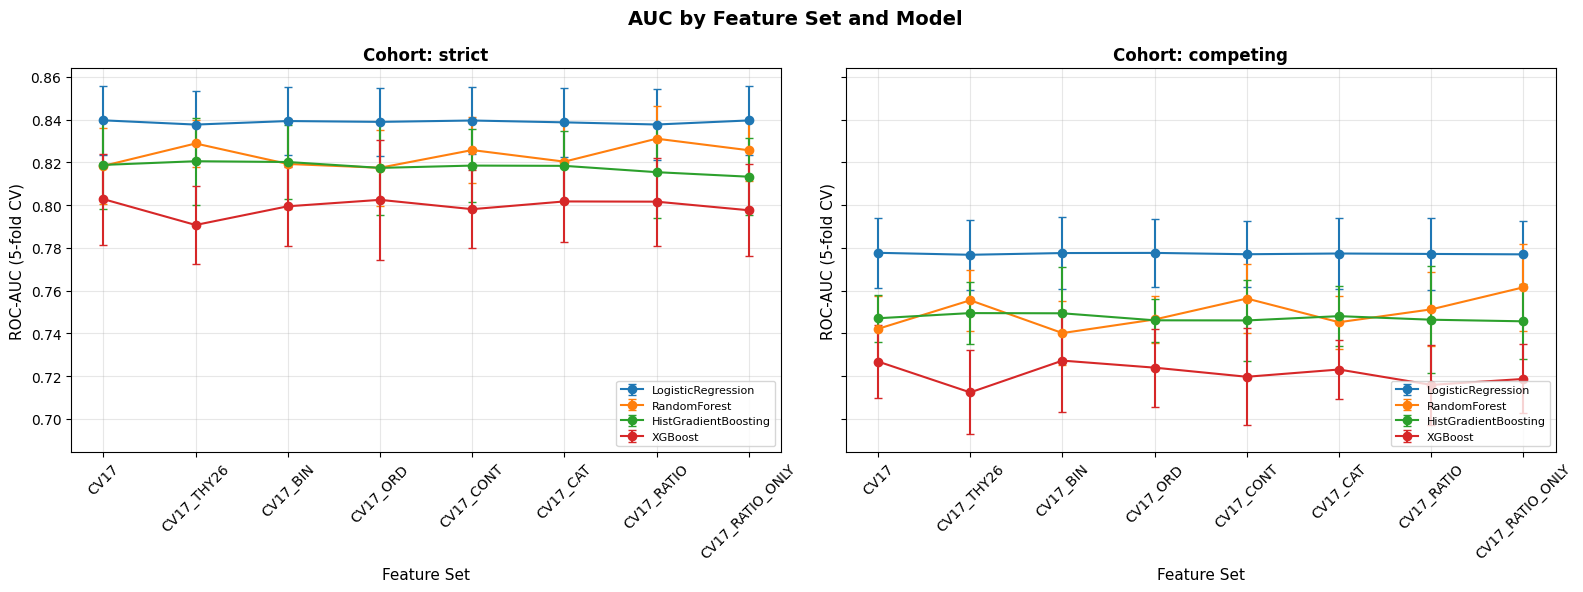

In [7]:
show_image(FIGURES / 'f1_by_feature_set.png', width=900)
show_image(FIGURES / 'auc_by_feature_set.png', width=900)

## Take-home message

- Use robust CV as the main classification evidence.
- Screening and tuning help explore model families, but the final claim should be based on cross-validated deltas versus `CV17`.
- If tuning completeness is not full, rerun `python run_pipeline.py --step tuning --force`.